# Using Linear Regression to Model Non-Linear Relationships

## Introduction

This notebook documents the development of a regression model to model a synthetic dataset with a non-linear relationship. 

The following approaches are taken to fit the data:

* [Simple Linear Regression](#simple-linear-regression)

* [Polynomial Regression](#polynomial-regression)

* [Spline Regression](#spline-regression), using:

  - [Natural Cubic Splines](#natural-cubic-splines)

  - [B-Splines](#b-spline-fitting)

After fitting the data with each approach, the fit is evaluated.

[Conclusions](#conclusions)

## Creating Synthetic Data to Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(777)

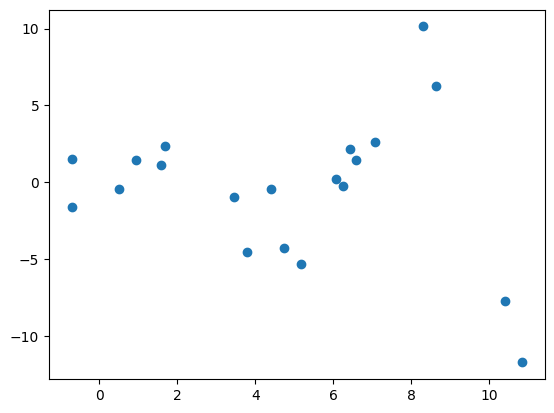

In [2]:
# create synthetic data, which is a noisy version of x*sin(x)
x = np.linspace(0, 10, 20) + np.random.normal(0, 1.5, size=(20,))
y = x*np.sin(x) + np.random.normal(0, 1.5, size=x.shape)

plt.scatter(x, y)
plt.show()

In [3]:
data = pd.DataFrame({'x': x, 'y': y})
data

,x,y
0,-0.702313,-1.621371
1,-0.707921,1.488598
2,0.954561,1.463116
3,0.508904,-0.444113
4,3.464789,-0.958365
5,3.780934,-4.570176
6,4.396976,-0.461011
7,1.698686,2.370114
8,1.581860,1.110954
9,6.240516,-0.234643


## Simple Linear Regression

We begin by attempting to model the dataset with a simple linear regression, the simplest kind of model. This has the advantage of being easily understood and interpretable. We already know this is going to be a poor fit, however, it is worth showcasing the steps to build the model and the evaluation steps that show it is a poor fit.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(data[['x']], data['y'], test_size=0.2, random_state=777)

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coef = model.coef_

intercept, coef

(np.float64(1.0825307021730182), array([-0.39450277]))

Regression Line:
$$
y = 1.083 - 0.395x
$$

In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

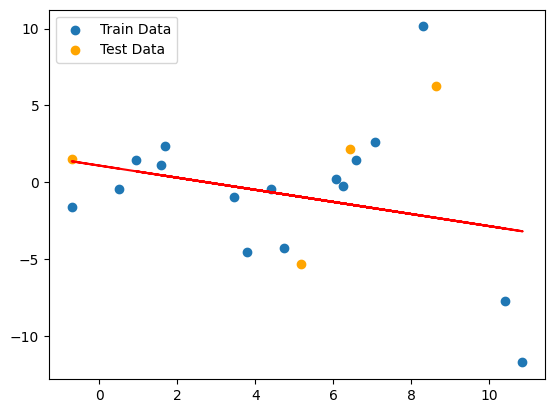

In [6]:
plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, color='orange', label="Test Data")
plt.plot(X_train, y_train_pred, color='red')
plt.legend()
plt.show()

### Checking Residuals and Evaluating Model Performance

In [7]:
residuals = y_train - y_train_pred
residual_mean = np.mean(residuals)
residual_mean

np.float64(2.7755575615628914e-16)

The mean of the residuals is virtually zero, which does not violate the assumptions of a linear relationship.

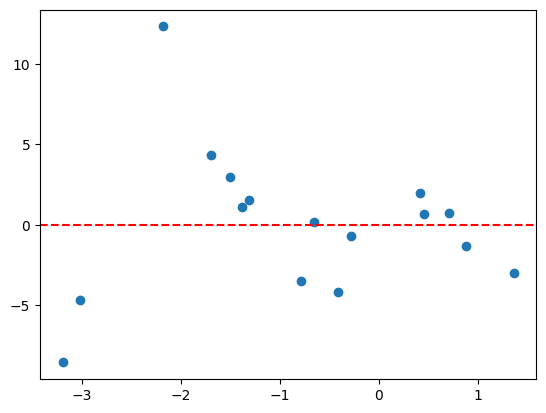

In [8]:
plt.scatter(y_train_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.show()

However, a potential non-linear trend can be seen in the residuals plot, indicating a linear fit is not appropriate.

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

training_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
training_r2 = r2_score(y_train, y_train_pred)

training_rmse, training_r2

(np.float64(4.494868419583066), 0.07908932943218039)

In [10]:
testing_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

testing_rmse

np.float64(5.127455346080741)

$$
y = 1.083 - 0.395x
$$
$$
R^{2} = 0.079
$$

* Training RMSE = 4.49

* Testing RMSE = 5.13


The regression line is poorly fit to the data and the testing error > training error. Poor predictive ability.

# Polynomial Regression

The next sensible course of action is to investigate whether a polynomial fit is better. This introduces higher order predictor terms ($x^{2}$, $x^{3}$, ...) into the model.

In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False) # include_bias=False to remove the intercept term for the model as we already have it in the LinearRegression model

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

model_poly.intercept_, model_poly.coef_

(np.float64(0.18210844607599652),
 array([-2.48262394,  0.84267689, -0.0642855 ]))

Regression Line:
$$
y = 0.182 - 2.483x + 0.843x^{2} - 0.064x^{3}
$$

In [12]:
x_poly_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_poly_plot = model_poly.predict(poly.transform(x_poly_plot))

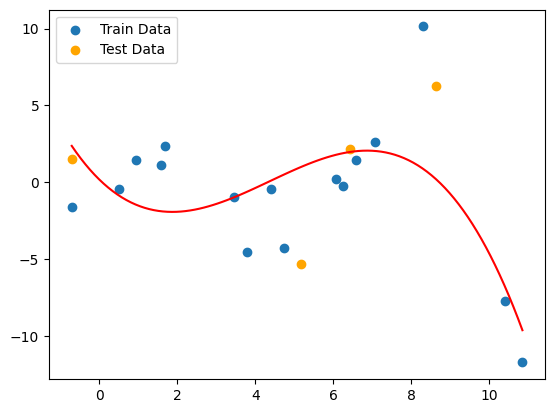

In [13]:
plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, color='orange', label="Test Data")
plt.plot(x_poly_plot, y_poly_plot, color='red')
plt.legend()
plt.show()

In [14]:
y_train_poly_pred = model_poly.predict(X_train_poly)
y_test_poly_pred = model_poly.predict(X_test_poly)

poly_training_rmse = np.sqrt(mean_squared_error(y_train, y_train_poly_pred))
poly_testing_rmse = np.sqrt(mean_squared_error(y_test, y_test_poly_pred))

poly_training_rmse, poly_testing_rmse

(np.float64(3.4358583214555507), np.float64(4.3870542771875325))

In [15]:
poly_R2 = r2_score(y_train, y_train_poly_pred)
poly_R2

0.4619110993155765

$$
y = 0.182 - 2.483x - 0.843x^{2} - 0.064x^{3}
$$
$$
R^{2} = 0.462
$$

* Training RMSE = 3.44

* Testing RMSE = 4.38

Improvement on simple linear regression. Errors are smaller, however testing error still remains noticeably greater than the training error, indicating poorer predictive ability. The $R^{2}$ of 0.462 is also relatively low, suggesting the model does not fit the training data very strongly.

## Spline Regression

We now move onto spline regression techniques. Splines are piecewise defined functions that utilise polynomials over a set of intervals to fit data. 

Splines are typically preferred to polynomial fits since they avoid Runge's phenomenon, where high order polynomial fits lead to severe oscillations in the generated curve near the boundaries of an interval.

## Natural Cubic Splines

In [16]:
train_order = X_train['x'].sort_values().index 
# sort X_train by the 'x' column to ensure that the data points are in the correct order for spline fitting and preserve order of indices for y_train as well.

X_train = X_train.loc[train_order].to_numpy().flatten() 
# convert the sorted X_train to a NumPy array and flatten it to a 1D array, which is the required format for fitting the spline.

y_train = y_train.loc[train_order] 
# sort y_train by the index to ensure that the target values are in the correct order corresponding to the sorted X_train

# repeat for test set
test_order = X_test['x'].sort_values().index 

X_test = X_test.loc[test_order].to_numpy().flatten()

y_test = y_test.loc[test_order]

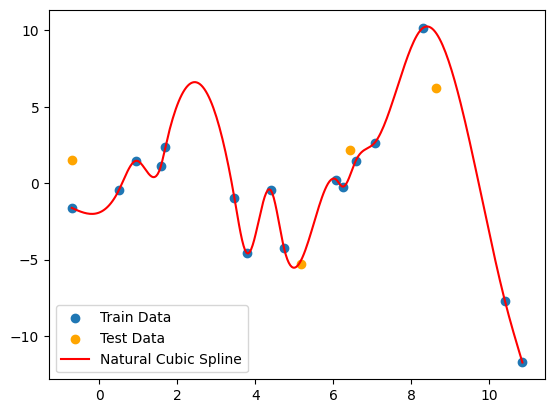

In [17]:
from scipy.interpolate import CubicSpline

y_naturalcubicspline = CubicSpline(X_train, y_train, bc_type='natural') 
# bc_type='natural' specifies that the second derivative at the endpoints should be zero, which is a common choice for natural cubic splines. This will produce a natural cubic spline interpolation of the data points in X_train and y_train. The curve will have C2 continuity and interpolate all the data points in X_train and y_train.

x_spline_plot = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
y_natural_cubic_spline_plot = y_naturalcubicspline(x_spline_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, color='orange', label="Test Data")
plt.plot(x_spline_plot, y_natural_cubic_spline_plot, color='red', label='Natural Cubic Spline')
plt.legend()
plt.show()

In [18]:
y_test_naturalcubicspline_pred = y_naturalcubicspline(X_test)

spline_testing_rmse = np.sqrt(mean_squared_error(y_test, y_test_naturalcubicspline_pred))
print("Natural Cubic Spline testing RMSE:", spline_testing_rmse)

Natural Cubic Spline testing RMSE: 2.519540744087399


The test datapoints are predicted more accurately than the third order polynomial fit, however, it is clear we are overfitting the data by appearance alone.

### Natural Cubic Spline Coefficients

15 piecewise cubic functions construct the spline, their coefficients are shown below:

In [19]:
natural_cubic_spline_coef = y_naturalcubicspline.c
natural_cubic_spline_coef

array([[ 1.44534522e+00, -1.64830196e+01,  2.51467929e+01,
        -1.09131211e+02,  1.17214334e-01,  5.58999329e+01,
        -5.04121639e+01,  7.10322254e+01, -1.10360224e+01,
         1.06248588e+02, -4.60825438e+01,  1.52891048e+01,
        -4.77104348e+00,  2.00296930e+00, -2.59152344e+00],
       [ 4.44089210e-16,  5.25188302e+00, -1.67854335e+01,
         3.05381731e+01, -7.71018320e+00, -7.08914539e+00,
         4.59282328e+01, -4.72397678e+01,  2.53165696e+01,
        -1.91446080e+01,  3.19004960e+01, -1.38165921e+01,
         8.43918224e+00, -9.19011159e+00,  3.48536867e+00],
       [-1.14842816e+00,  5.21274537e+00,  7.27385316e-02,
         8.69980606e+00,  1.13667275e+01, -1.47704132e+01,
        -2.49164720e+00, -3.29960758e+00, -1.07641396e+01,
        -2.47574640e+00, -4.32972179e-01,  5.54719123e+00,
         2.93796020e+00,  2.01305043e+00, -1.00208096e+01],
       [-1.62137131e+00, -4.44112522e-01,  1.46311609e+00,
         1.11095356e+00,  2.37011368e+00, -9.58364943

The knots for the spline are given by the 16 training points:

In [20]:
X_train

array([-0.70231319,  0.50890448,  0.95456143,  1.58185953,  1.69868635,
        3.46478949,  3.78093404,  4.39697584,  4.73746139,  6.08037208,
        6.24051571,  6.57120555,  7.05642634,  8.28811314, 10.3975614 ,
       10.8458651 ])

The resulting spline is a piecewise defined function constructed from the following polynomials. Only the first three are shown for conciseness, but all can be extracted from the coefficient matrix above.

Segment 1: [-0.702, 0.509]
$$
y = -2.77x^{3} + 6.62x - 1.62
$$
Segment 2: [0.509, 0.955]
$$
y = 29.21x^{3} - 10.08x^{2} - 5.59x + 1.46
$$
Segment 3: [0.955, 1.582]
$$ 
y = −55.483x^{3} + 28.980x^{2} + 2.834x − 0.444
$$

*etc.*

## B-Spline Fitting

Using a B-spline (Basis Spline) will yield a more generalised fit since these splines do not interpolate every training point. 

B-splines are still C2 continuous and retain local control (meaning the shape of the curve does not vary much when one training point is changed), making it ideal for fitting a general trend.

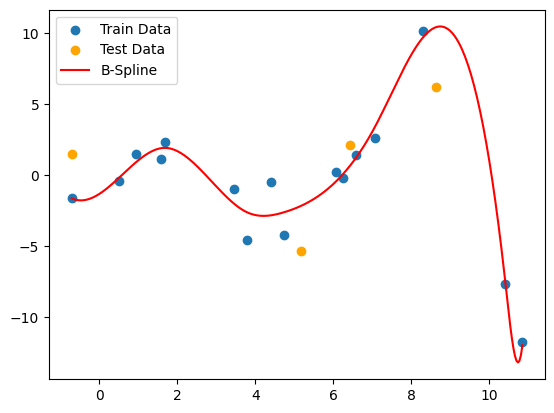

In [21]:
from scipy.interpolate import UnivariateSpline

y_b_spline = UnivariateSpline(X_train, y_train, k=3) # k=3 specifies that we want to fit a cubic B-spline to the data points in X_train and y_train. When the smoothing parameter, s, is not set, the UnivariateSpline class will automatically determine the knot positions based on the data and fit a cubic B-spline that interpolates the data points. The resulting spline will have C2 continuity and will be a smooth curve that provides a general fit to the data.

x_spline_plot = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
y_b_spline_plot = y_b_spline(x_spline_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, color='orange', label="Test Data")
plt.plot(x_spline_plot, y_b_spline_plot, color='red', label='B-Spline')
plt.legend()
plt.show()

In [22]:
y_train_b_spline_pred = y_b_spline(X_train)

b_spline_training_rmse = np.sqrt(mean_squared_error(y_train, y_train_b_spline_pred))

y_test_b_spline_pred = y_b_spline(X_test)

b_spline_testing_rmse = np.sqrt(mean_squared_error(y_test, y_test_b_spline_pred))

print("B-Spline training RMSE:", b_spline_training_rmse)
print("=========================================")
print("B-Spline testing RMSE:", b_spline_testing_rmse)

B-Spline training RMSE: 0.999814729887576
B-Spline testing RMSE: 3.141457825071782


The results of the B-spline fit is certainly more generalized than the natural cubic spline, however, we are still observing moderately large testing errors, suggesting the predictive power of this model could be improved. 

Improvement could come about by acquiring more data since only 16 data points were used to train the model. The model has not been exposed to a large enough range of training datapoints to sufficiently fit a general pattern - there will be a high uncertainty in the fitted spline, particularly in areas of the feature space where there are a lack of datapoints.

Additionally, the smoothing parameter, s, can be adjusted.

## Fitting a B-Spline After Collecting More Data (and adjusting smoothing)

We can simulate the process of gathering more data:

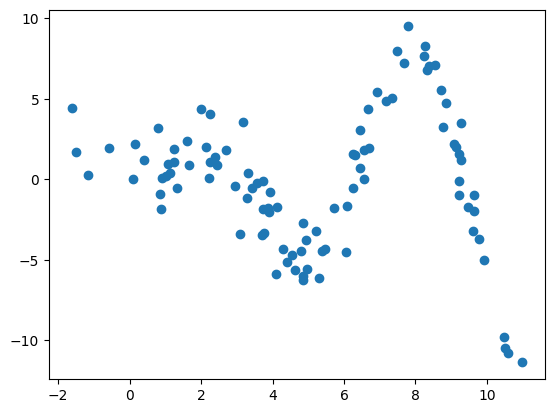

In [23]:
x = np.linspace(0, 10, 100) + np.random.normal(0, 1.5, size=(100,))
y = x*np.sin(x) + np.random.normal(0, 1.5, size=x.shape)

data = pd.DataFrame({"x": x, "y": y})

plt.scatter(data["x"], data["y"])
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(data[['x']], data['y'], test_size=0.2, random_state=777)

train_order = X_train['x'].sort_values().index 
# sort X_train by the 'x' column to ensure that the data points are in the correct order for spline fitting and preserve order of indices for y_train as well.

X_train = X_train.loc[train_order].to_numpy().flatten() 
# convert the sorted X_train to a NumPy array and flatten it to a 1D array, which is the required format for fitting the spline.

y_train = y_train.loc[train_order] 
# sort y_train by the index to ensure that the target values are in the correct order corresponding to the sorted X_train

# repeat for test set
test_order = X_test['x'].sort_values().index 

X_test = X_test.loc[test_order].to_numpy().flatten()

y_test = y_test.loc[test_order]

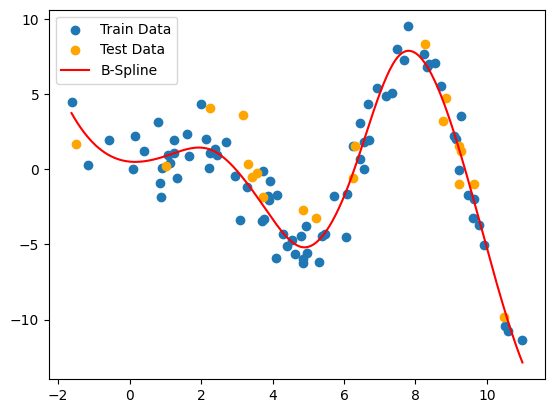

In [25]:
y_b_spline = UnivariateSpline(X_train, y_train, k=3, s=135)
# k=3 specifies that we want to fit a cubic B-spline to the data points. The smoothing parameter, s=135, controls the amount of smoothing applied to the spline. A larger value of s will result in a smoother spline that may not interpolate all the data points, while a smaller value of s will result in a spline that closely follows the data points. By setting s=140, we are allowing for some smoothing while still trying to capture the overall trend of the data.

x_spline_plot = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)
y_b_spline_plot = y_b_spline(x_spline_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, color='orange', label="Test Data")
plt.plot(x_spline_plot, y_b_spline_plot, color='red', label='B-Spline')
plt.legend()
plt.show()

In [26]:
y_train_b_spline_pred = y_b_spline(X_train)

b_spline_training_rmse = np.sqrt(mean_squared_error(y_train, y_train_b_spline_pred))

y_test_b_spline_pred = y_b_spline(X_test)

b_spline_testing_rmse = np.sqrt(mean_squared_error(y_test, y_test_b_spline_pred))

print("B-Spline training RMSE:", b_spline_training_rmse)
print("=========================================")
print("B-Spline testing RMSE:", b_spline_testing_rmse)

B-Spline training RMSE: 1.2988517504679786
B-Spline testing RMSE: 1.6608400915317318


Setting the smoothing parameter to 135 has provided small training and testing RMSEs. These errors are comparable, which indicates the model is performing quite well at predicting unseen data. The fact that the RMSE is slightly greater for the test set indicates the model is slightly overfitted, but this is to be expected for modelling complicated relationships. 

Alternative values for the smoothing parameter lead to larger testing errors with even more pronounced overfitting, so a compromise must be reached.

Additionally, with the collection of more data, we can be more certain that the trend that has been identified is a good representation of the data.

## Conclusions

We have successfully created a predictive regression model that captures the non-linear relationship. The most successful model was found to be a B-Spline Regression Model (with a smoothing parameter `s` of 135). 

It can be used to predict y values given an unseen x value:

In [27]:
y_b_spline(2.25)

array(1.31416803)